# Self-Guided Laboratory Session

## Image Enhancement and Morphological Image Processing

**Duration:** 2 hours  
**Tasks:** brightness and contrast adjustment, histogram equalization, smoothing filters, sharpening, unsharp masking, morphological processing, and segmentation.

## Learning Outcomes

- Adjust image brightness and contrast using intensity transformations.
- Improve image contrast using histogram equalization.
- Compare average, Gaussian, and median smoothing filters.
- Apply sharpening and unsharp masking.
- Use thresholding, erosion, dilation, opening, closing, and connected components for object counting.

## Setup

Set `IMAGE_PATH` to your own image file if required. If it is left as `None`, the notebook creates sample images so every task can be completed without extra files.

In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 11

# Optional: replace None with a local image path, for example "sample.jpg".
IMAGE_PATH = "/content/images.jpg"


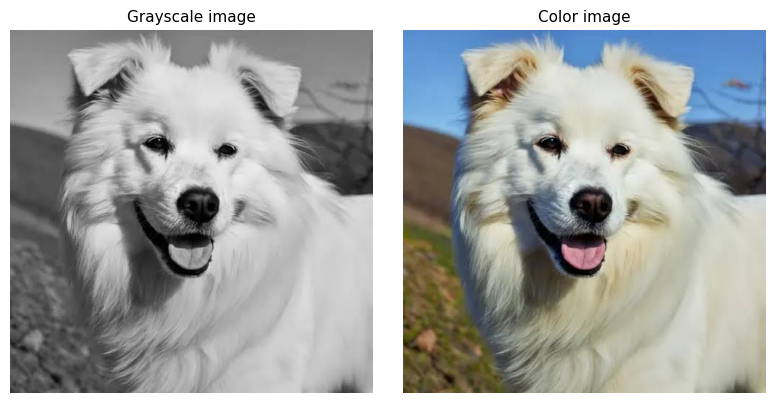

In [23]:
def show_images(titles, images, cols=None, figsize=None):
    """Display grayscale or BGR/RGB images in a compact grid."""
    total = len(images)
    cols = cols or total
    rows = int(np.ceil(total / cols))
    figsize = figsize or (4 * cols, 4 * rows)
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    for ax, title, image in zip(axes, titles, images):
        if image.ndim == 2:
            ax.imshow(image, cmap="gray", vmin=0, vmax=255)
        else:
            ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        ax.set_title(title)
        ax.axis("off")

    for ax in axes[total:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


def create_sample_image():
    """Create a deterministic sample image for enhancement operations."""
    height, width = 320, 420
    gradient = np.tile(np.linspace(35, 220, width, dtype=np.uint8), (height, 1))
    gray = gradient.copy()

    cv2.circle(gray, (110, 150), 65, 210, -1)
    cv2.rectangle(gray, (235, 75), (370, 205), 85, -1)
    cv2.line(gray, (35, 260), (390, 260), 145, 8)
    cv2.putText(gray, "IP Lab", (118, 292), cv2.FONT_HERSHEY_SIMPLEX, 1.15, 245, 3)

    color = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    cv2.circle(color, (110, 150), 65, (70, 160, 235), -1)
    cv2.rectangle(color, (235, 75), (370, 205), (90, 190, 100), -1)
    cv2.putText(color, "IP Lab", (118, 292), cv2.FONT_HERSHEY_SIMPLEX, 1.15, (245, 245, 245), 3)
    return gray, color


def load_or_create_image(image_path=None):
    if image_path is not None and Path(image_path).exists():
        color = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
        if color is None:
            raise ValueError(f"Could not read image: {image_path}")
        gray = cv2.cvtColor(color, cv2.COLOR_BGR2GRAY)
        return gray, color

    return create_sample_image()


gray_img, color_img = load_or_create_image(IMAGE_PATH)
show_images(["Grayscale image", "Color image"], [gray_img, color_img], cols=2)


## Task 1: Brightness and Contrast Adjustment

**Deliverable:** original image, brightness +50, brightness -50, and contrast x1.5.

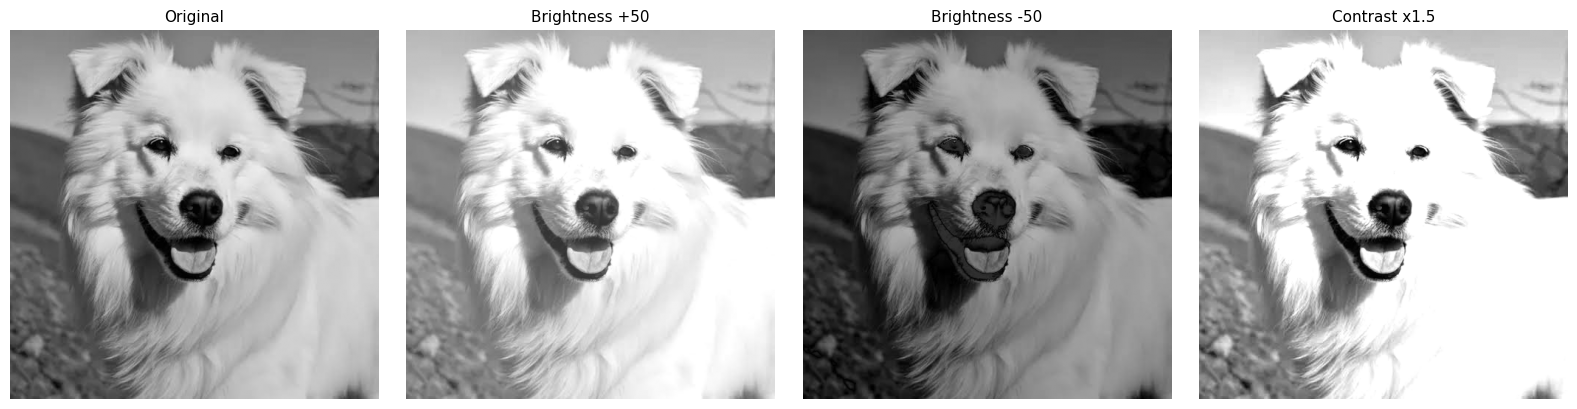

In [24]:
def adjust_brightness(image, value):
    return cv2.convertScaleAbs(image, alpha=1.0, beta=value)


def adjust_contrast(image, factor):
    return cv2.convertScaleAbs(image, alpha=factor, beta=0)


brightness_plus_50 = adjust_brightness(gray_img, 50)
brightness_minus_50 = adjust_brightness(gray_img, -50)
contrast_1_5 = adjust_contrast(gray_img, 1.5)

show_images(
    ["Original", "Brightness +50", "Brightness -50", "Contrast x1.5"],
    [gray_img, brightness_plus_50, brightness_minus_50, contrast_1_5],
    cols=4,
    figsize=(16, 4),
)


## Task 2: Histogram Equalization

Apply histogram equalization and compare the histogram before and after processing.

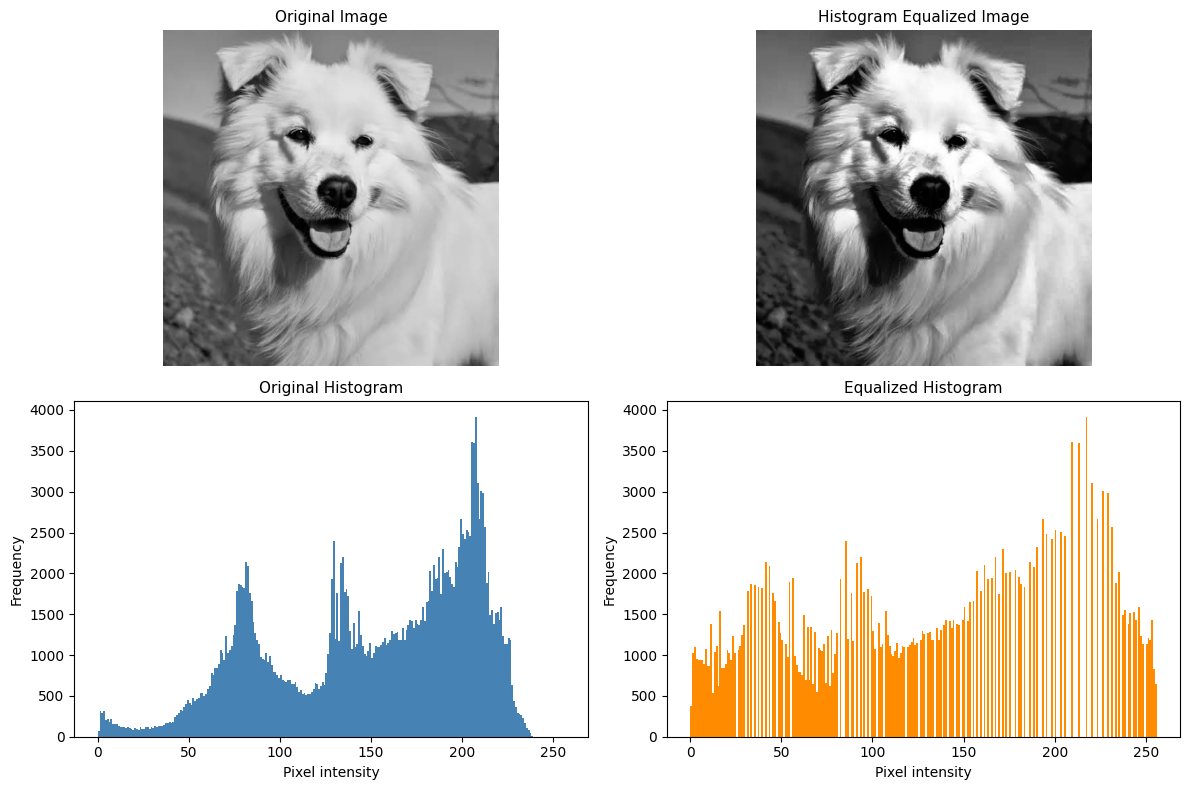

In [25]:
equalized_img = cv2.equalizeHist(gray_img)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].imshow(gray_img, cmap="gray", vmin=0, vmax=255)
axes[0, 0].set_title("Original Image")
axes[0, 0].axis("off")

axes[0, 1].imshow(equalized_img, cmap="gray", vmin=0, vmax=255)
axes[0, 1].set_title("Histogram Equalized Image")
axes[0, 1].axis("off")

axes[1, 0].hist(gray_img.ravel(), bins=256, range=(0, 256), color="steelblue")
axes[1, 0].set_title("Original Histogram")
axes[1, 0].set_xlabel("Pixel intensity")
axes[1, 0].set_ylabel("Frequency")

axes[1, 1].hist(equalized_img.ravel(), bins=256, range=(0, 256), color="darkorange")
axes[1, 1].set_title("Equalized Histogram")
axes[1, 1].set_xlabel("Pixel intensity")
axes[1, 1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


## Task 3: Smoothing Filters

Compare average, Gaussian, and median filters on a noisy image.

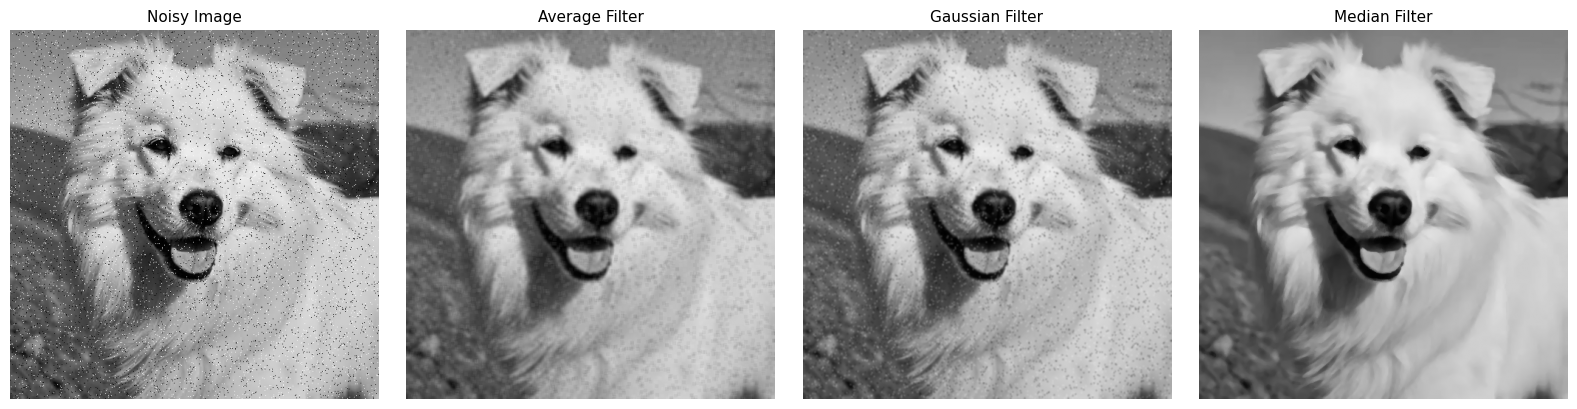

In [26]:
def add_salt_and_pepper_noise(image, amount=0.04, salt_vs_pepper=0.5, seed=7):
    noisy = image.copy()
    rng = np.random.default_rng(seed)
    total_pixels = image.size

    salt_count = int(total_pixels * amount * salt_vs_pepper)
    pepper_count = int(total_pixels * amount * (1 - salt_vs_pepper))

    salt_rows = rng.integers(0, image.shape[0], salt_count)
    salt_cols = rng.integers(0, image.shape[1], salt_count)
    noisy[salt_rows, salt_cols] = 255

    pepper_rows = rng.integers(0, image.shape[0], pepper_count)
    pepper_cols = rng.integers(0, image.shape[1], pepper_count)
    noisy[pepper_rows, pepper_cols] = 0
    return noisy


noisy_img = add_salt_and_pepper_noise(gray_img)
average_filtered = cv2.blur(noisy_img, (5, 5))
gaussian_filtered = cv2.GaussianBlur(noisy_img, (5, 5), sigmaX=0)
median_filtered = cv2.medianBlur(noisy_img, 5)

show_images(
    ["Noisy Image", "Average Filter", "Gaussian Filter", "Median Filter"],
    [noisy_img, average_filtered, gaussian_filtered, median_filtered],
    cols=4,
    figsize=(16, 4),
)


## Task 4: Sharpening and Unsharp Masking

Create a blurred image, extract a mask, and generate sharpened outputs.

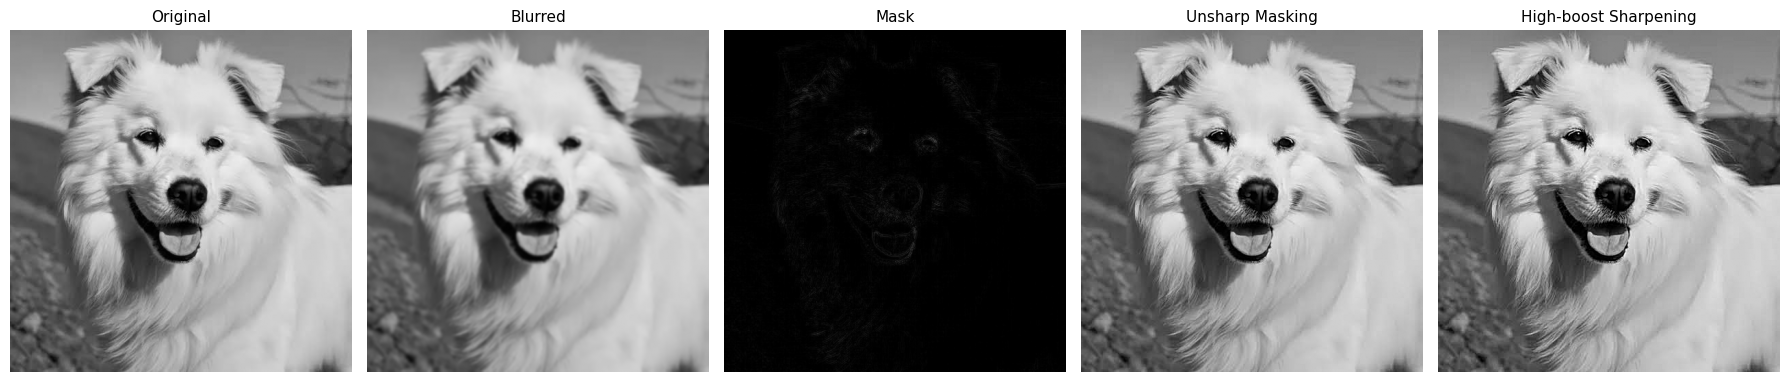

In [27]:
blurred_img = cv2.GaussianBlur(gray_img, (7, 7), sigmaX=0)

# The absolute mask is easier to display; signed subtraction is used inside addWeighted.
mask_img = cv2.absdiff(gray_img, blurred_img)
unsharp_img = cv2.addWeighted(gray_img, 1.5, blurred_img, -0.5, 0)
high_boost_img = cv2.addWeighted(gray_img, 2.0, blurred_img, -1.0, 0)

show_images(
    ["Original", "Blurred", "Mask", "Unsharp Masking", "High-boost Sharpening"],
    [gray_img, blurred_img, mask_img, unsharp_img, high_boost_img],
    cols=5,
    figsize=(18, 4),
)


## Task 5: Morphological Processing and Segmentation

Threshold the image, perform erosion, dilation, opening, and closing, then count the objects using connected components.

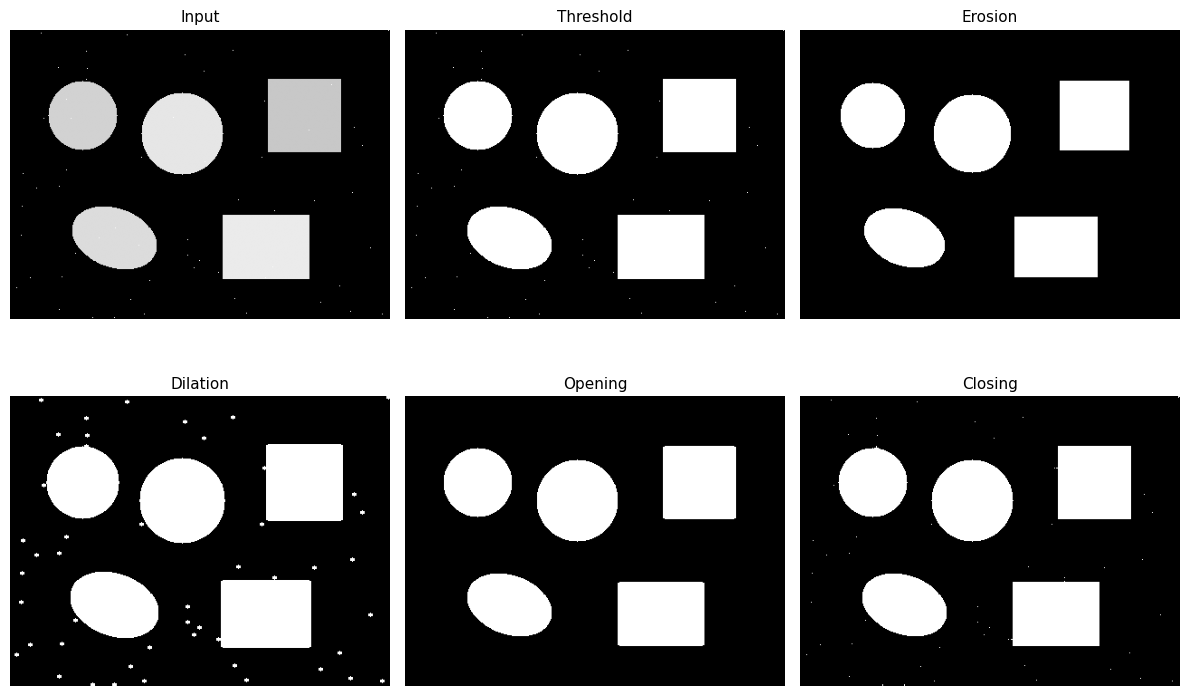

In [28]:
def create_segmentation_sample():
    image = np.zeros((320, 420), dtype=np.uint8)
    cv2.circle(image, (80, 95), 38, 210, -1)
    cv2.circle(image, (190, 115), 45, 230, -1)
    cv2.rectangle(image, (285, 55), (365, 135), 200, -1)
    cv2.ellipse(image, (115, 230), (48, 32), 20, 0, 360, 220, -1)
    cv2.rectangle(image, (235, 205), (330, 275), 235, -1)

    rng = np.random.default_rng(11)
    for _ in range(60):
        row = rng.integers(0, image.shape[0])
        col = rng.integers(0, image.shape[1])
        image[row, col] = 255

    return image


segmentation_img = create_segmentation_sample()
_, binary_img = cv2.threshold(segmentation_img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
eroded_img = cv2.erode(binary_img, kernel, iterations=1)
dilated_img = cv2.dilate(binary_img, kernel, iterations=1)
opened_img = cv2.morphologyEx(binary_img, cv2.MORPH_OPEN, kernel)
closed_img = cv2.morphologyEx(binary_img, cv2.MORPH_CLOSE, kernel)

show_images(
    ["Input", "Threshold", "Erosion", "Dilation", "Opening", "Closing"],
    [segmentation_img, binary_img, eroded_img, dilated_img, opened_img, closed_img],
    cols=3,
    figsize=(12, 8),
)


Object count after opening with minimum area 100: 5


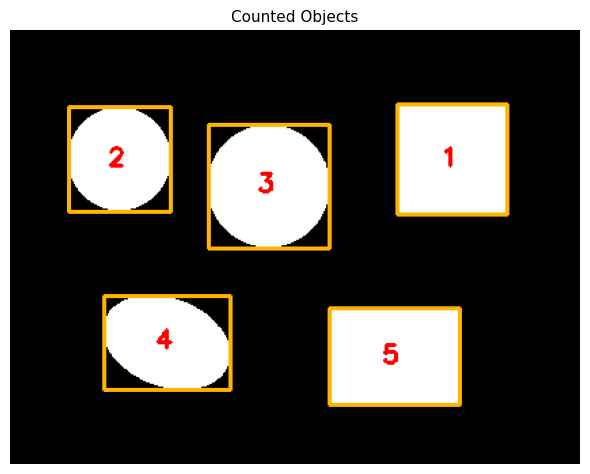

In [29]:
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(opened_img, connectivity=8)

min_area = 100
object_count = 0
count_visualization = cv2.cvtColor(opened_img, cv2.COLOR_GRAY2BGR)

for label_id in range(1, num_labels):
    area = stats[label_id, cv2.CC_STAT_AREA]
    if area < min_area:
        continue

    object_count += 1
    x = stats[label_id, cv2.CC_STAT_LEFT]
    y = stats[label_id, cv2.CC_STAT_TOP]
    w = stats[label_id, cv2.CC_STAT_WIDTH]
    h = stats[label_id, cv2.CC_STAT_HEIGHT]
    cx, cy = centroids[label_id]

    cv2.rectangle(count_visualization, (x, y), (x + w, y + h), (0, 180, 255), 2)
    cv2.putText(
        count_visualization,
        str(object_count),
        (int(cx) - 8, int(cy) + 5),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 0, 255),
        2,
    )

print(f"Object count after opening with minimum area {min_area}: {object_count}")
show_images(["Counted Objects"], [count_visualization], cols=1, figsize=(6, 5))


## Additional Segmentation Techniques

This section covers the remaining segmentation methods: global thresholding, adaptive thresholding, Otsu thresholding, edge-based segmentation, region growing, watershed, and k-means clustering.

### Thresholding: Global, Adaptive, and Otsu

Global thresholding uses one fixed threshold value. Adaptive thresholding computes local thresholds for small neighborhoods. Otsu's method automatically selects a threshold from the image histogram.

Otsu threshold value: 140.00


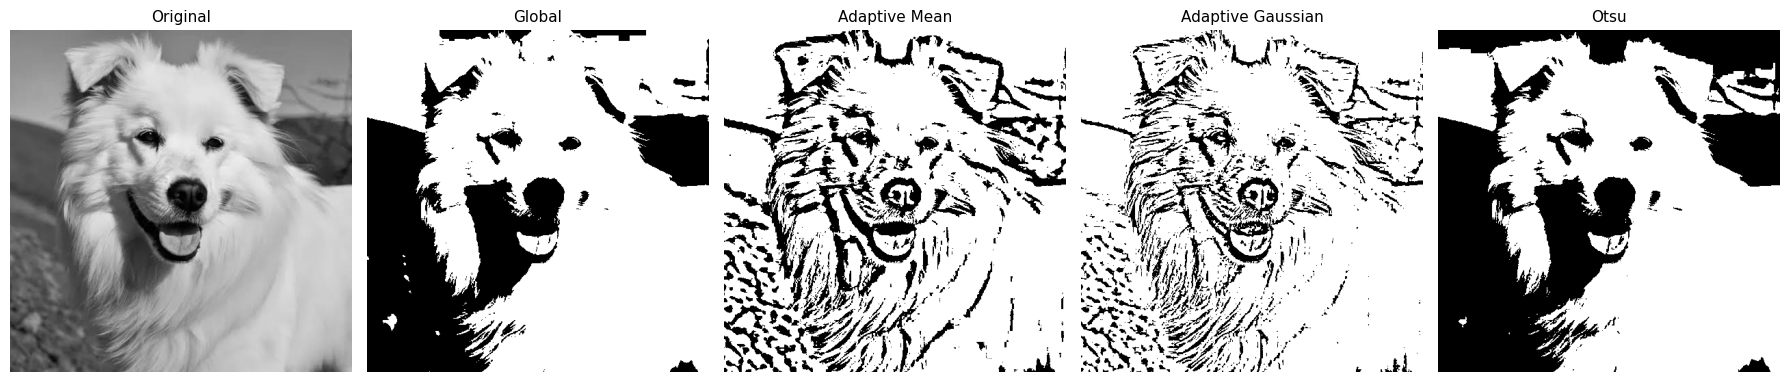

In [30]:
_, global_threshold = cv2.threshold(gray_img, 127, 255, cv2.THRESH_BINARY)

adaptive_mean_threshold = cv2.adaptiveThreshold(
    gray_img,
    255,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY,
    21,
    5,
)

adaptive_gaussian_threshold = cv2.adaptiveThreshold(
    gray_img,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    21,
    5,
)

otsu_value, otsu_threshold = cv2.threshold(gray_img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

print(f"Otsu threshold value: {otsu_value:.2f}")
show_images(
    ["Original", "Global", "Adaptive Mean", "Adaptive Gaussian", "Otsu"],
    [gray_img, global_threshold, adaptive_mean_threshold, adaptive_gaussian_threshold, otsu_threshold],
    cols=5,
    figsize=(18, 4),
)


### Edge-Based Segmentation

Edge-based segmentation detects strong intensity changes. The common operators below are Canny, Sobel, Laplacian, and Prewitt.

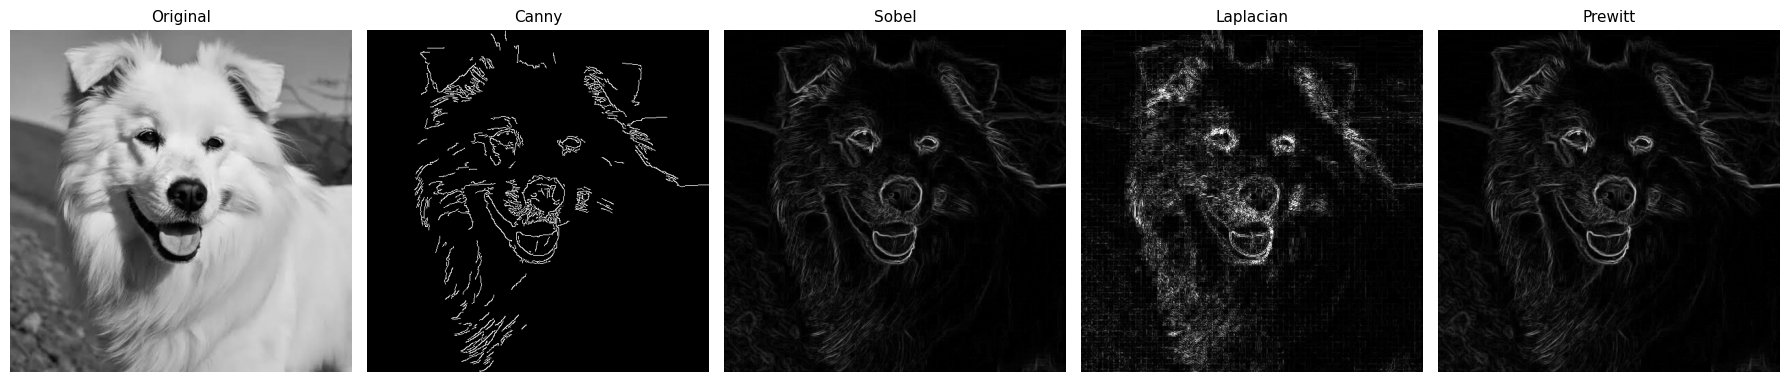

In [31]:
canny_edges = cv2.Canny(gray_img, 100, 200)

sobel_x = cv2.Sobel(gray_img, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(gray_img, cv2.CV_64F, 0, 1, ksize=3)
sobel_magnitude = cv2.magnitude(sobel_x, sobel_y)
sobel_edges = cv2.normalize(sobel_magnitude, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

laplacian = cv2.Laplacian(gray_img, cv2.CV_64F, ksize=3)
laplacian_edges = cv2.convertScaleAbs(laplacian)

prewitt_kernel_x = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], dtype=np.float32)
prewitt_kernel_y = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]], dtype=np.float32)
prewitt_x = cv2.filter2D(gray_img, cv2.CV_32F, prewitt_kernel_x)
prewitt_y = cv2.filter2D(gray_img, cv2.CV_32F, prewitt_kernel_y)
prewitt_magnitude = cv2.magnitude(prewitt_x, prewitt_y)
prewitt_edges = cv2.normalize(prewitt_magnitude, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

show_images(
    ["Original", "Canny", "Sobel", "Laplacian", "Prewitt"],
    [gray_img, canny_edges, sobel_edges, laplacian_edges, prewitt_edges],
    cols=5,
    figsize=(18, 4),
)


### Region-Based Segmentation: Region Growing

Region growing starts from a seed pixel and extends the region to neighboring pixels with similar intensity.

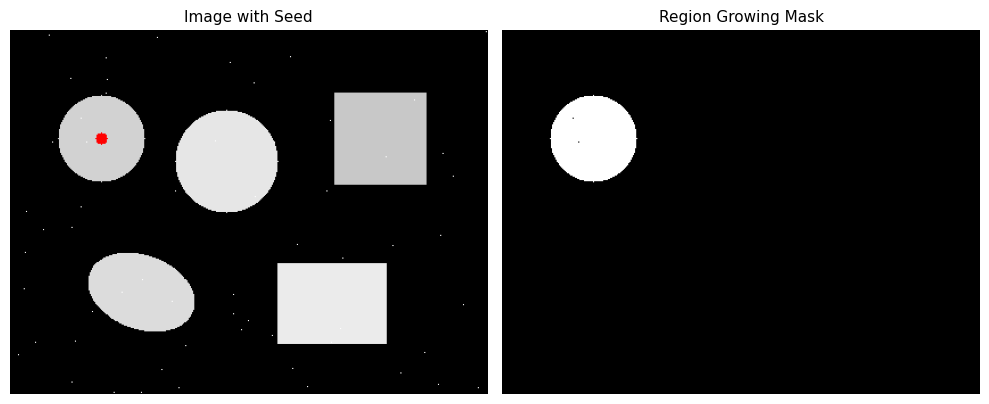

In [32]:
def region_growing(image, seed, similarity_threshold=25):
    height, width = image.shape
    seed_row, seed_col = seed
    seed_value = int(image[seed_row, seed_col])
    visited = np.zeros_like(image, dtype=bool)
    region = np.zeros_like(image, dtype=np.uint8)
    stack = [(seed_row, seed_col)]

    while stack:
        row, col = stack.pop()
        if row < 0 or row >= height or col < 0 or col >= width or visited[row, col]:
            continue

        visited[row, col] = True
        if abs(int(image[row, col]) - seed_value) > similarity_threshold:
            continue

        region[row, col] = 255
        stack.extend(
            [
                (row - 1, col),
                (row + 1, col),
                (row, col - 1),
                (row, col + 1),
            ]
        )

    return region


seed_point = (95, 80)  # row, column inside the first circular object
region_mask = region_growing(segmentation_img, seed_point, similarity_threshold=35)
seed_visualization = cv2.cvtColor(segmentation_img, cv2.COLOR_GRAY2BGR)
cv2.circle(seed_visualization, (seed_point[1], seed_point[0]), 5, (0, 0, 255), -1)

show_images(
    ["Image with Seed", "Region Growing Mask"],
    [seed_visualization, region_mask],
    cols=2,
    figsize=(10, 4),
)


### Watershed Segmentation

Watershed treats the image as a topographic surface and separates touching or nearby regions using marker labels.

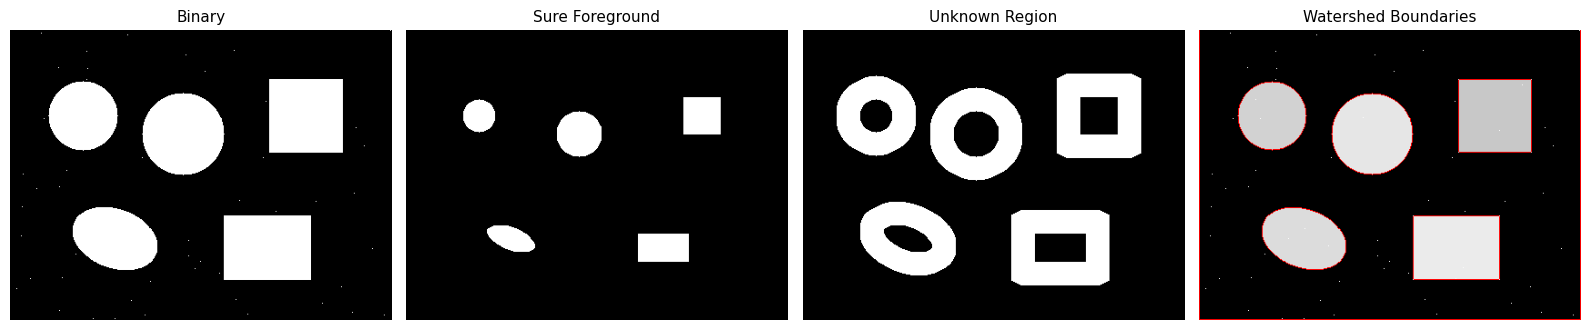

In [33]:
_, watershed_binary = cv2.threshold(segmentation_img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
watershed_opening = cv2.morphologyEx(watershed_binary, cv2.MORPH_OPEN, kernel, iterations=2)

sure_background = cv2.dilate(watershed_opening, kernel, iterations=3)
distance_transform = cv2.distanceTransform(watershed_opening, cv2.DIST_L2, 5)
_, sure_foreground = cv2.threshold(distance_transform, 0.45 * distance_transform.max(), 255, 0)
sure_foreground = sure_foreground.astype(np.uint8)
unknown_region = cv2.subtract(sure_background, sure_foreground)

_, watershed_markers = cv2.connectedComponents(sure_foreground)
watershed_markers = watershed_markers + 1
watershed_markers[unknown_region == 255] = 0

watershed_input = cv2.cvtColor(segmentation_img, cv2.COLOR_GRAY2BGR)
watershed_result = cv2.watershed(watershed_input, watershed_markers)
watershed_visualization = watershed_input.copy()
watershed_visualization[watershed_result == -1] = [0, 0, 255]

show_images(
    ["Binary", "Sure Foreground", "Unknown Region", "Watershed Boundaries"],
    [watershed_binary, sure_foreground, unknown_region, watershed_visualization],
    cols=4,
    figsize=(16, 4),
)


### K-Means Clustering-Based Segmentation

K-means groups pixels into clusters based on intensity values. Each cluster becomes one segmented intensity class.

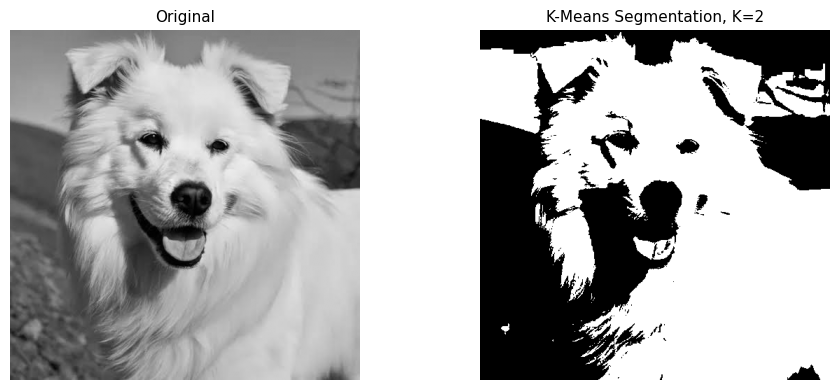

In [34]:
pixel_values = gray_img.reshape((-1, 1)).astype(np.float32)

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
cluster_count = 2
_, cluster_labels, cluster_centers = cv2.kmeans(
    pixel_values,
    cluster_count,
    None,
    criteria,
    10,
    cv2.KMEANS_RANDOM_CENTERS,
)

# Map cluster centers to black (0) and white (255)
# Determine which cluster center is darker and assign it to 0, the other to 255
segmented_colors = np.zeros(cluster_centers.shape, dtype=np.uint8)
if cluster_centers[0] < cluster_centers[1]:
    segmented_colors[0] = 0   # Darker cluster becomes black
    segmented_colors[1] = 255 # Lighter cluster becomes white
else:
    segmented_colors[0] = 255 # Lighter cluster becomes white
    segmented_colors[1] = 0   # Darker cluster becomes black

kmeans_segmented = segmented_colors[cluster_labels.flatten()].reshape(gray_img.shape)

show_images(
    ["Original", f"K-Means Segmentation, K={cluster_count}"],
    [gray_img, kmeans_segmented],
    cols=2,
    figsize=(10, 4),
)

## Evaluation Checklist

- Code runs without missing image files because sample images are generated when needed.
- Each task displays the required outputs for comparison.
- Morphological operations use a defined structuring element.
- Object counting is performed after opening to reduce small noise components.